# Batch correction with scPoli (scArches conditional VAE)

scPoli (De Donno et al., *Nat Methods* 2023) is a conditional VAE from the scArches ecosystem that learns one or more per-condition prototypes in the latent space. When given cell-type labels (`cell_type_keys`), the prototypes anchor each cell type across batches, improving batch removal and enabling prototype-based label transfer to query datasets.

This is one of the **omicverse batch-correction zoo** tutorials. See [batch/index](../index.md) for the overview / decision tree, or [../t_single_batch](../t_single_batch.ipynb) for the side-by-side comparison of every backend on a real benchmark.

## Load a 2-batch demo from pbmc3k

We use the canonical 10x pbmc3k dataset and synthesise a 2-batch label by random assignment, then plant a gene-shift on `batch_B` so the uncorrected UMAP shows a visible batch effect. This keeps the notebook self-contained and fast (~2 min end-to-end) — for a real multi-donor benchmark with [scib-metrics] scoring, see [../t_single_batch](../t_single_batch.ipynb).

In [1]:
import omicverse as ov
ov.style()
import anndata as ad
import numpy as np
import pandas as pd

# NeurIPS 2021 multimodal hematopoiesis dataset — 3 real donor batches
# (s1d3, s2d1, s3d7), pre-annotated `cell_type` and raw `layers['counts']`.
# Same datasets used by the overview notebook ../t_single_batch.ipynb.
adata1 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932005',
    filename='neurips2021_s1d3.h5ad',
)
adata2 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932008',
    filename='neurips2021_s2d1.h5ad',
)
adata3 = ov.datasets.get_adata(
    'https://figshare.com/ndownloader/files/41932011',
    filename='neurips2021_s3d7.h5ad',
)
adata = ad.concat([adata1, adata2, adata3], merge='same')
adata.var_names_make_unique()
adata.obs_names_make_unique()
adata.obs['batch'] = adata.obs['batch'].astype('category')

# Subsample to a quick-running ~6 000 cells × 3 batches so the CPU
# backends (harmony / combat / scanorama / cca) finish in well under a
# minute. Drop this line for a full-resolution run.
_rng = np.random.default_rng(0)
_sel = _rng.choice(adata.n_obs, 6000, replace=False)
adata = adata[_sel].copy()
adata

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

⚠️ File ./data/neurips2021_s1d3.h5ad already exists
 Loading data from ./data/neurips2021_s1d3.h5ad


✅ Successfully loaded: 5935 cells × 13953 genes
⚠️ File ./data/neurips2021_s2d1.h5ad already exists
 Loading data from ./data/neurips2021_s2d1.h5ad


✅ Successfully loaded: 10258 cells × 13953 genes
⚠️ File ./data/neurips2021_s3d7.h5ad already exists
 Loading data from ./data/neurips2021_s3d7.h5ad


✅ Successfully loaded: 11230 cells × 13953 genes


AnnData object with n_obs × n_vars = 6000 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

## Preprocess + PCA + cluster

Same QC → HVG-pearson → log-norm → PCA pipeline shared across every backend in the zoo. A quick Leiden cluster gives a synthetic `celltype` label that scANVI / scPoli can use as a prototype anchor.

In [2]:
# Standard omicverse preprocess (QC → HVG-via-pearson → log-norm → PCA).
# QC thresholds are loose because the NeurIPS data is already filtered.
adata = ov.pp.qc(adata, tresh={'mito_perc': 0.2, 'nUMIs': 200,
                                 'detected_genes': 100})
ov.utils.store_layers(adata, layers='counts')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000,
                         batch_key=None)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features].copy()
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)

# Neighbours graph for the pre-correction UMAP.
ov.pp.neighbors(adata, use_rep='scaled|original|X_pca', n_neighbors=15)

# The NeurIPS adata already carries a real `cell_type` annotation —
# rename it to `celltype` for the wrapper's expected schema. No Leiden
# needed; the labels are pre-annotated by the dataset authors.
adata.obs['celltype'] = adata.obs['cell_type'].astype('category')
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 94                 │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 11                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 44 cells, 0 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.040
   ✓ scDblFinder completed: 169 doublets removed (2.8%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 27.1331s                                                │
│  Shape:    6,000 x 13,953 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚

    After filtration, 13953/13953 genes are kept.
    Among 13953 genes, 13953 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 6 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC', 'HBB', 'MALAT1', 'HBA2', 'IGLC2', 'IGLC3']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 5,786 cells × 13,953 genes
   ✓ Runtime: 0.26s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 13,953 total (14.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.99 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.1515s                                                 │
│  Shape:    5,786 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 5786x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (5786, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (2.41s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 2.409s                                                  │
│  Shape:    5,786 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 5786x30)                               │
│           │ ✚ scaled|original|X_pca (array, 5786x30)               │
│         

   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 5,786 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 7.7794s                                                 │
│  Shape:    5,786 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivit

AnnData object with n_obs × n_vars = 5786 × 2000
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'predicted_doublet', 'doublet_score', 'scdblfinder_doublet', 'scdblfinder_score', 'celltype'
    var: 'feature_types', 'gene_id', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'hig

## Uncorrected baseline

The planted batch effect is visible in the uncorrected UMAP:

🔍 [2026-05-29 05:07:38] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distance: 0.3
{'n_neighbors': 15, 'method': 'umap', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca'}
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (classic method)...



✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 5,786 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.9129s                                                 │
│  Shape:    5,786 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.9921756195894755), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 5786x2)                               │
│                 

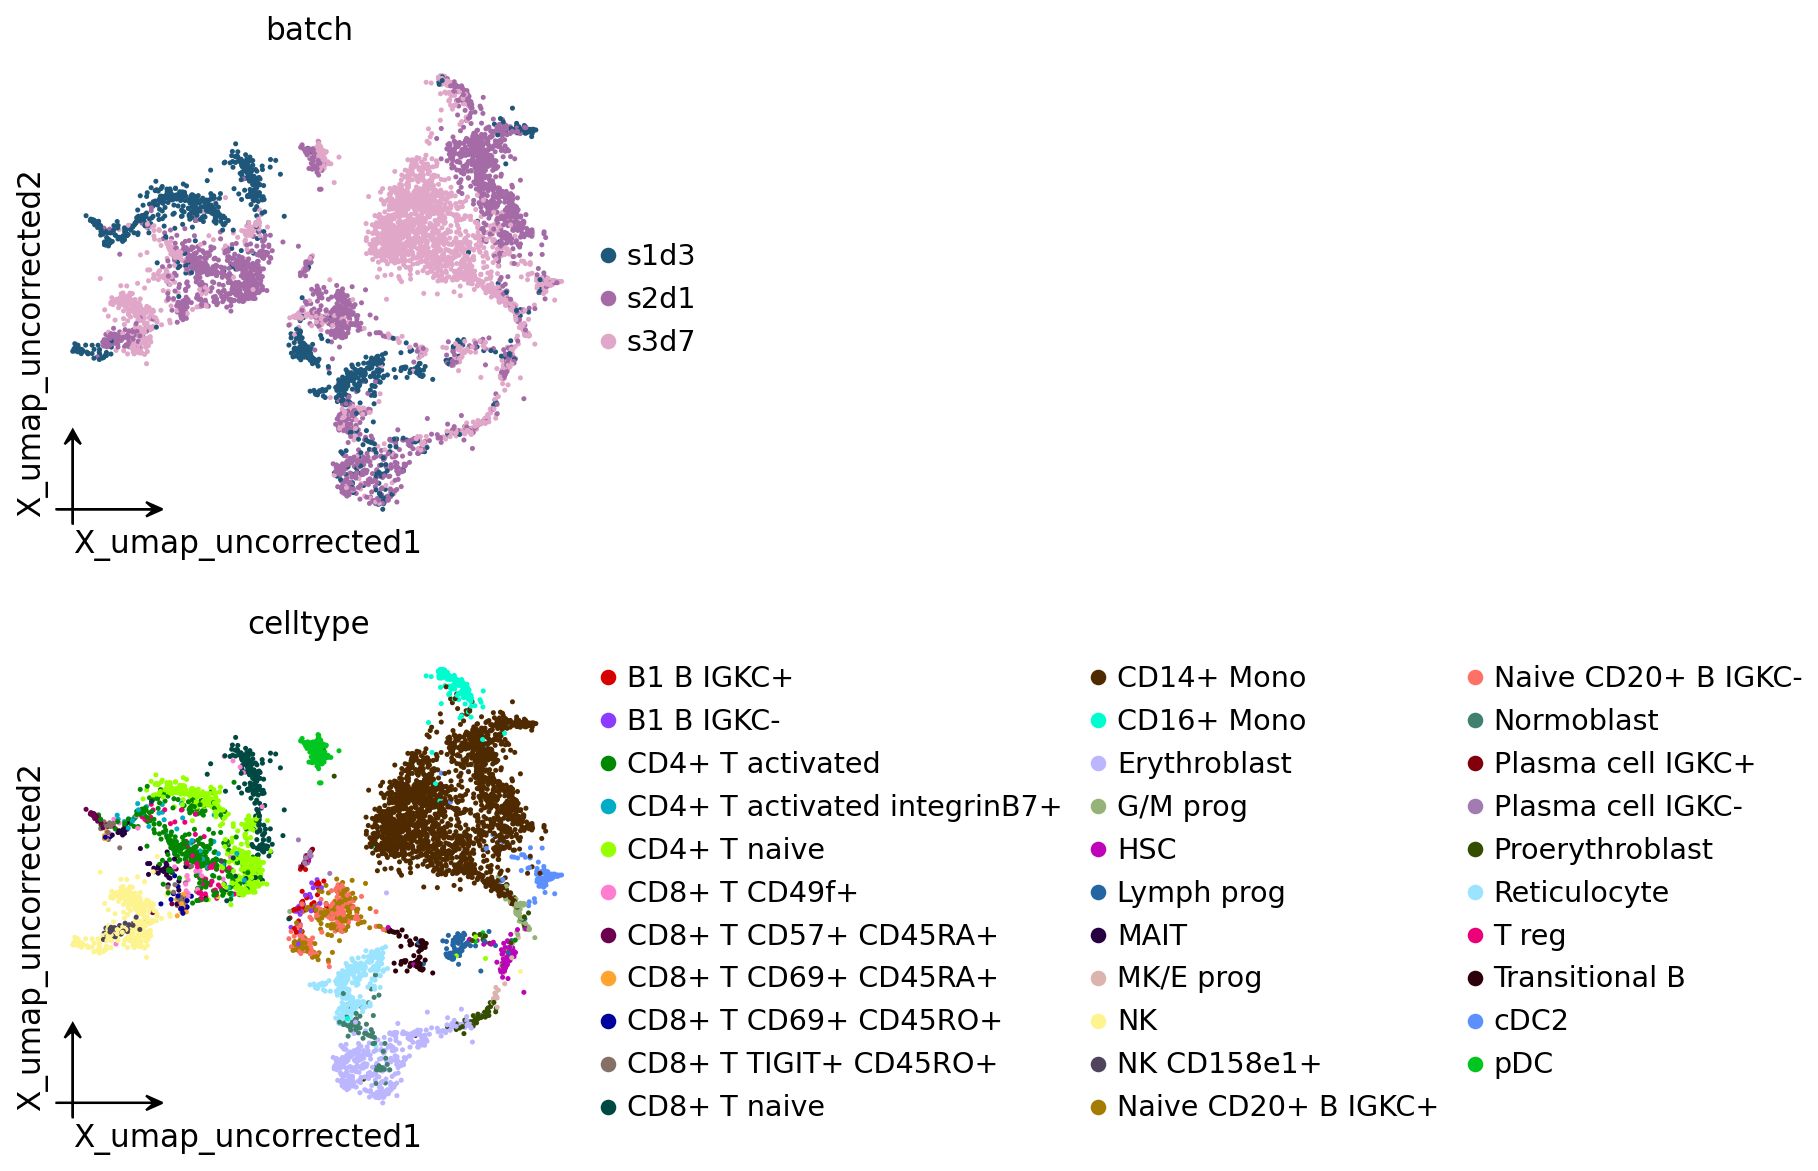

In [3]:
# Pre-correction UMAP shows the planted batch effect.
ov.pp.umap(adata, min_dist=0.3)
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()
ov.pl.embedding(adata, basis='X_umap_uncorrected',
                color=['batch', 'celltype'],
                frameon='small', wspace=0.5)

## Run `ov.single.batch_correction(methods='scpoli')`

For the scvi-tools family backends, the wrapper auto-routes `**kwargs` between the model's `__init__` (architecture) and `.train()` (optimisation) destinations. See the **Key parameters** section below.

In [4]:
# Workaround: scArches 0.6.1 scPoli.get_latent passes a torch bool
# tensor to scipy sparse indexing, which scipy >=1.16 rejects with
# AttributeError. Densify .X (HVG-only, ~46 MB for this demo)
# before training — fixes the latent extraction call.
import scipy.sparse as sp
if sp.issparse(adata.X):
    adata.X = adata.X.toarray()

model = ov.single.batch_correction(
    adata,
    batch_key='batch',
    methods='scPoli',
    # Optional but recommended — enables prototype learning:
    cell_type_keys='celltype',
    # All scPoli architecture + training kwargs left at defaults.
)
model


...Begin using scPoli to correct batch effect


 captum (see https://github.com/pytorch/captum).


Embedding dictionary:
 	Num conditions: [3]
 	Embedding dim: [10]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 10
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 10
	Output Layer in/out:  45 2000 



INFO:scarches.trainers.scpoli.trainer:GPU available: True, GPU used: True


Initializing dataloaders
Starting training


...

 |███████████████████-| 97.0%  - val_loss: 1981.71 - val_cvae_loss: 1969.68 - val_prototype_loss:   12.03 - val_labeled_loss:   12.03

 |███████████████████-| 98.0%  - val_loss: 1969.35 - val_cvae_loss: 1958.46 - val_prototype_loss:   10.89 - val_labeled_loss:   10.89

 |███████████████████-| 99.0%  - val_loss: 1970.54 - val_cvae_loss: 1959.50 - val_prototype_loss:   11.04 - val_labeled_loss:   11.04

 |████████████████████| 100.0%  - val_loss: 1990.40 - val_cvae_loss: 1979.16 - val_prototype_loss:   11.24 - val_labeled_loss:   11.24



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 33.0495s                                                │
│  Shape:    5,786 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ conditions_combined (category)                       │
│                                                                    │
│  ● OBSM   │ ✚ X_scPoli (array, 5786x10)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


## Corrected embedding

Every backend writes its corrected representation to a stable obsm key — for this one it is `adata.obsm['X_scPoli']`. We project via `ov.utils.mde` for a lightweight UMAP-style display.

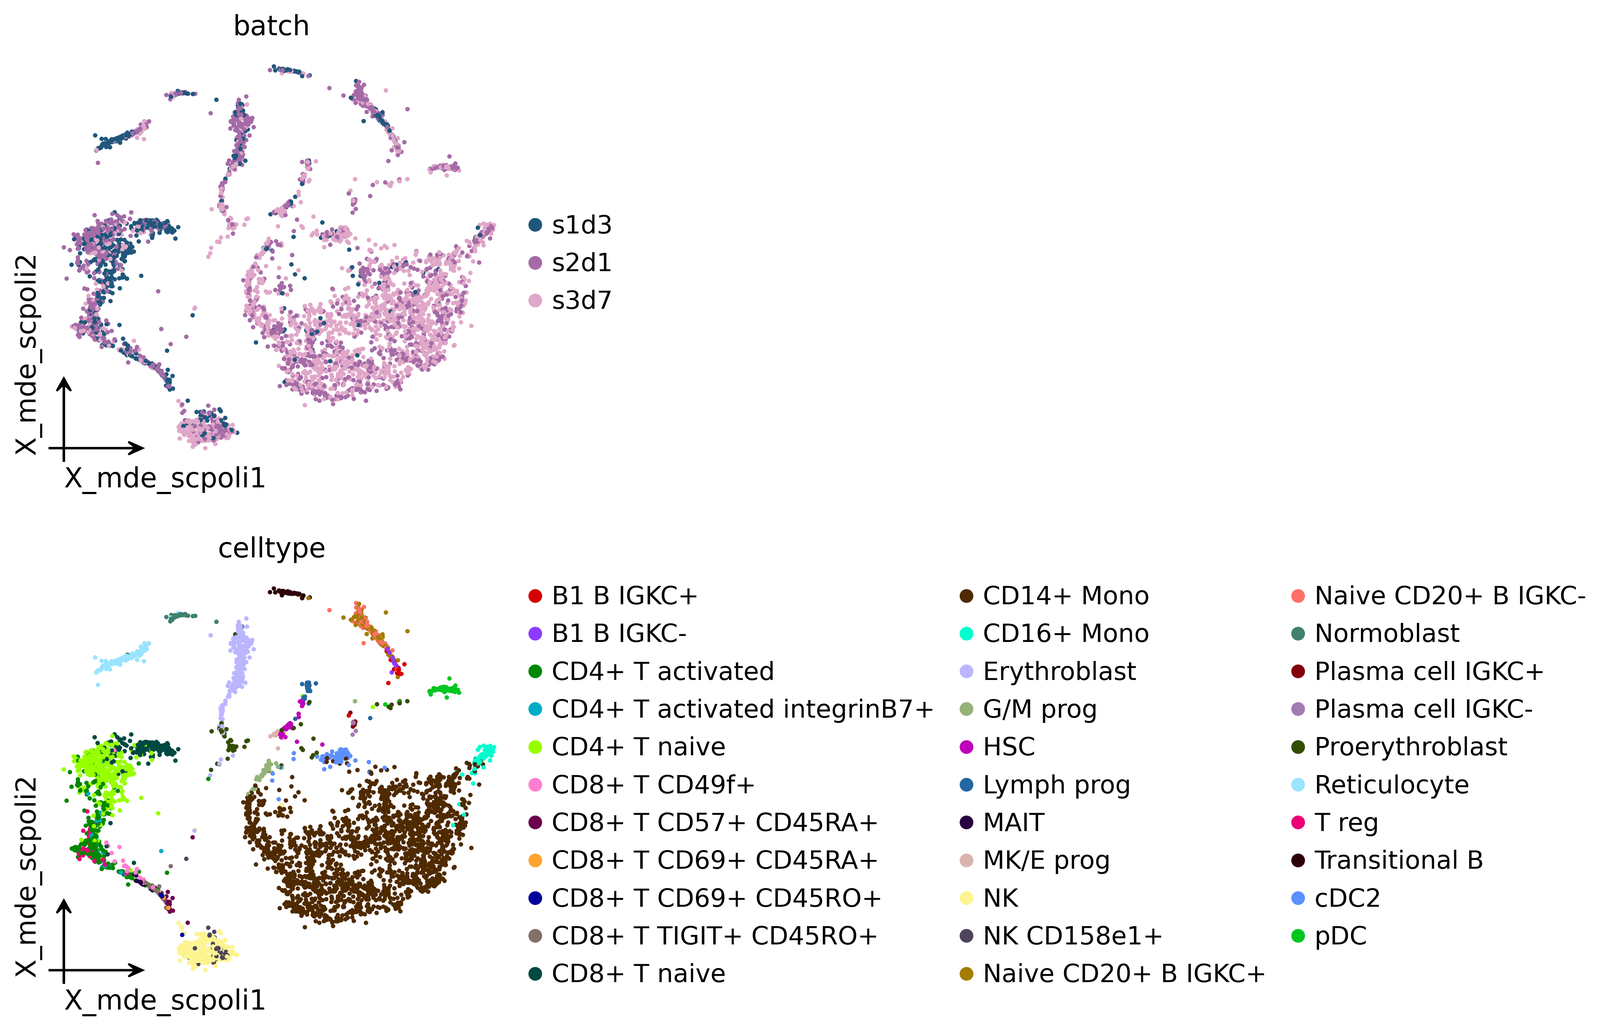

In [5]:
adata.obsm['X_mde_scpoli'] = ov.utils.mde(adata.obsm['X_scPoli'])
ov.pl.embedding(
    adata,
    basis='X_mde_scpoli',
    color=['batch', 'celltype'],
    frameon='small',
    wspace=0.5,
)

## Key parameters

**Optional (recommended)**:
- `cell_type_keys` — obs column(s) for prototype learning.

**Architecture** (→ `scPoli.__init__`):
- `embedding_dims`, `recon_loss` ∈ {`'nb'`, `'zinb'`, `'mse'`}, `latent_dim`.

**Optimisation** (→ `scPoli.train`):
- `n_epochs`, `pretraining_epochs`, `eta`, `early_stopping_kwargs`.


## Related tutorials

- [t_batch_scanvi](t_batch_scanvi.ipynb) — alternative semi-supervised approach.
- [t_batch_scvi](t_batch_scvi.ipynb) — fully unsupervised alternative.

For the full side-by-side comparison with scib-metrics scoring, see [../t_single_batch](../t_single_batch.ipynb).